In [1]:
# Created by alexander.kukalev@mdc-berlin.de, 2023

import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

In [2]:
def coordinates_from_location_string (region):
    chrom = region.split(':')[0]
    if len (region.split(':')) == 1:
        start, stop = 0, 0
    else:
        coordinates = region.split(':')[1]
        start = coordinates.split('-') [0]
        stop = coordinates.split ('-') [1]
        start = int(start.replace(',', ''))
        stop = int(stop.replace(',', ''))
    if start > stop:
        raise Exception ('Check coordinates of your region! It can not end before the start')
    return chrom, start, stop  

def get_region_from_location_string (segregation_table, region):
    import pandas as pd
    import numpy as np
    if len (segregation_table.index.names) == 1: # Check if supplied segregation table has multiindex
        segregation_table.set_index(['chrom','start','stop'], inplace = True) 
    chrom, start, stop = coordinates_from_location_string (region)
    seg_chrome = segregation_table.loc [chrom] # Subset for chromosome
    if start=='' and stop =='':
        return seg_chrome
    else:
        start_values = np.array (seg_chrome.index.get_level_values('start'))
        step = start_values [1] - start_values [0] # Find the resolution from table 
        closest_start_value = start_values[np.abs(start_values-start).argmin()]# Find start coordinate closest to start of the region
        if start < closest_start_value: # Make sure region start is included in the subset
            closest_start_value = closest_start_value - step
        stop_values = np.array (seg_chrome.index.get_level_values('stop'))
        closest_stop_value = stop_values[np.abs(stop_values-stop).argmin()]# Find stop coordinate closest to end of the region
        if stop > closest_stop_value: # Make sure region stop is included in the subset
            closest_stop_value = closest_stop_value + step
        start_values = np.array (seg_chrome.index.get_level_values('start'))
        last_bin_of_the_chromosome = np.max (start_values)
        if closest_stop_value > last_bin_of_the_chromosome:
            raise Exception ('Check coordinates of your region! The chromosome is shorter than specified range')
        return seg_chrome.loc [closest_start_value:closest_stop_value-step]

def calculate_NPMI (segregation_table, region):
    import warnings
    warnings.filterwarnings('ignore')
    import numpy as np
    import pandas as pd
    subset_segtable = get_region_from_location_string (segregation_table, region)
    seg_matrix = subset_segtable.values
    M = len(seg_matrix[0]) # calculate M the number of samples
    pxy = (seg_matrix.dot(seg_matrix.T))/M #calculate p(x,y) matrix i.e coseg matrix divided my M
    #p(x)p(y) matrix  - i.e detection frequency with the dot product of it's transposed self equals an N*N matrix
    pxpy = seg_matrix.sum(1).reshape(-1,1)/M * seg_matrix.sum(1)/M
    PMI = np.log2(pxy/pxpy) #define PMI matrix
    NPMI = PMI/-np.log2(pxy) #bound values between -1 and 1
    return NPMI

def get_ticks (segregation_table, region):
    import numpy as np
    chrom, start, stop = coordinates_from_location_string (region)
    seg_chrome = segregation_table.loc [chrom] # Subset for chromosome
    if start=='' and stop =='':
        start_values = np.array (seg_chrome.index.get_level_values('start'))
        start = 0
        stop = np.max (start_values)
        total_bins = len (seg_chrome)
    else:
        seg_table = get_region_from_location_string (segregation_table, region)
        total_bins = len (seg_table)
    middle = int(start + ((stop - start) / 2))
    middle_bin = int (total_bins / 2)
    return middle_bin, total_bins, start, middle, stop

def get_npmi_scale (matrix):
    import numpy as np
    matrix_con = np.concatenate (matrix)
    matrix_remove_nans = matrix_con[~np.isnan(matrix_con)]
    minscale = 0
    maxscale = np.percentile (matrix_remove_nans, 99)
    return minscale, maxscale


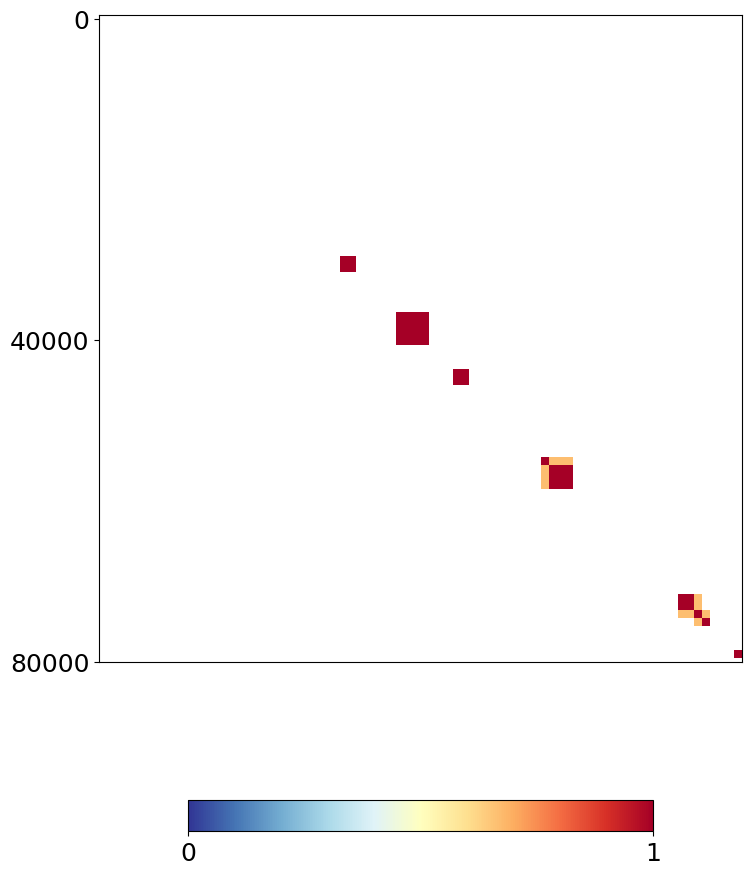

In [3]:
# Plotting data
file_path = "../test_out/sim_sample_run.1000.both.segregation.tsv"
region = 'chr9:0-80000'

# Plotting code
segregation_table = pd.read_csv (file_path, sep='\t', index_col=[0,1,2])
npmi_matrix = calculate_NPMI (segregation_table, region)

minscale1, maxscale1 = get_npmi_scale (npmi_matrix)
middle_bin, end_bin, start, middle, end = get_ticks (segregation_table, region)

f = plt.figure(figsize=(12,12))
plt.rcParams.update({'font.size': 18}) 

matrix_plt = plt.imshow(npmi_matrix, interpolation='none', cmap='RdYlBu_r', vmin=minscale1, vmax=maxscale1)
plt.yticks ([0,middle_bin,end_bin], [start, middle, end])
plt.xticks ([], [])
plt.colorbar(matrix_plt, ticks = (minscale1, maxscale1), orientation='horizontal', shrink = 0.5, aspect=15)
plt.show()